In [1]:
!pip install dill
!pip install gensim
!pip install --upgrade numpy gensim
!pip install pymorphy3
!pip install fasttext
!pip install --upgrade pip
!pip install --upgrade numpy pandas scipy scikit-learn gensim torch

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.datasets import make_classification
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import keras
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import dill

import pandas as pd

In [2]:
tqdm.pandas()
np.set_printoptions(precision=3, suppress=True)

In [3]:
df = pd.read_pickle('/content/dataset_with_model_vectors (1).pkl')

In [4]:
df['w2v_features'][0].shape

(100,)

In [5]:
df

,norm,ttype,tokens,w2v_features,word_to_vec_loaded,fast_text_features,fast_text_loaded
0,работа полный пиддес каждый закрытие месяц сви...,0,"[работа, полный, пиддес, каждый, закрытие, мес...","[0.7376642, -0.63502425, -0.25100532, 0.688579...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.2754487, 0.010388846, -0.09337636, -0.0213...","[-2.8524015e-05, -0.02114207, 0.014387419, 0.0..."
1,коллега сидеть рубиться изз долбать винд мочь,0,"[коллега, сидеть, рубиться, изз, долбать, винд...","[0.08297413, -0.31301978, -0.48485878, -0.4391...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.21833374, 0.25704786, 0.092399344, -0.0660...","[0.07968112, -0.028001538, 0.06807278, -0.0625..."
2,говорить обещаной год ждать,0,"[говорить, обещаной, год, ждать]","[0.6881826, -1.4032255, -1.304418, -0.36763868...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.39493644, -0.14916821, -0.17962919, 0.1968...","[0.012949028, -0.0373013, -0.008395562, -0.007..."
3,желать хороший полёт удачный посадкия быть оче...,0,"[желать, хороший, полёт, удачный, посадкия, бы...","[0.5427054, 0.031745836, 0.009401599, -1.09656...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.38330948, 0.021724677, 0.08339887, 0.30743...","[0.03786959, -0.0055939797, 0.019714734, 0.021..."
4,обновить какимтый леший работать простоплеер,0,"[обновить, какимтый, леший, работать, простопл...","[0.20956567, -0.7371343, 0.21360317, 0.1619571...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.44207597, 0.3887147, -0.06547135, -0.15484...","[-0.01707895, -0.008487223, -0.00036525782, 0...."
...,...,...,...,...,...,...,...
226829,спасть родительский дом свой кровать проснутьс...,1,"[спасть, родительский, дом, свой, кровать, про...","[1.1526381, -0.22993891, -0.9205229, -0.138405...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.16261089, 0.15368395, -0.29834577, 0.10277...","[0.026712425, -0.025714938, -0.036907338, 0.00..."
226830,эх немного решить сократить путь лежать мягкий...,1,"[эх, немного, решить, сократить, путь, лежать,...","[0.5184226, -0.21834773, -0.15892617, -0.17921...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.3688053, 0.2798581, -0.03681158, 0.1463447...","[0.03926708, -0.034269374, -0.0013539005, -0.0..."
226831,происходить я эфир звучать любимый песня,1,"[происходить, я, эфир, звучать, любимый, песня]","[-0.0800403, 0.4339986, -0.4724648, -0.931411,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.32492915, 0.35778224, -0.35182473, 0.34271...","[0.015655609, -0.039198965, -0.0389552, -0.013..."
226832,любимаять подарить ты звезда имя звезда перево...,1,"[любимаять, подарить, ты, звезда, имя, звезда,...","[-0.1747475, 0.2250355, 0.57660323, 0.33068973...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.29170376, -0.137013, -0.17001458, 0.130004...","[0.031720426, -0.029329607, -0.018305225, -0.0..."


Model initialisation

In [6]:
def sentiment_analysis_model(input_shape):
    model = Sequential([
    Dense(128, activation='relu', input_shape=(input_shape,)),  # Входной слой
    Dropout(0.5),  # Dropout для предотвращения переобучения
    Dense(64, activation='relu'),  # Скрытый слой
    Dropout(0.5),  # Еще один Dropout
    Dense(1, activation='sigmoid')
    ])

    return model

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def sentiment_analysis_model(input_shape):
    model = Sequential([
    Dense(256, activation='relu', input_shape=(input_shape,)),  # Входной слой
    BatchNormalization(),  # Нормализация активаций
    Dropout(0.5),  # Dropout для предотвращения переобучения
    Dense(128, activation='relu'),  # Скрытый слой
    BatchNormalization(),  # Нормализация активаций
    Dropout(0.5),  # Еще один Dropout
    Dense(64, activation='relu'),  # Скрытый слой
    BatchNormalization(),  # Нормализация активаций
    Dropout(0.3),  # Меньший Dropout
    Dense(1, activation='sigmoid')  # Выходной слой (бинарная классификация)
    ])

    return model

In [8]:
def sentiment_analysis_model(input_shape):
    model = Sequential()

    model.add(Input(shape=(input_shape,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid'))

    return model

In [9]:
def save_model(model: tf.keras.Model):
    os.makedirs('saved_models', exist_ok=True)
    os.makedirs('saved_models/' + str(date.today()), exist_ok=True)
    path = 'saved_models/' + str(date.today()) + '/'

    model.save_weights(path + 'weights_speech_intelligibility_assessment' + '.weights.h5')
    model.save(path + 'model_speech_intelligibility_assessment' + '.keras')

In [10]:
def save_history(history):
    os.makedirs('saved_models', exist_ok=True)
    os.makedirs('saved_models/' + str(date.today()), exist_ok=True)
    path = 'saved_models/' + str(date.today()) + '/'
    history_filename = path + 'history_speech_intelligibility_assessment' + '.pkl'
    with open(history_filename, 'wb') as f:
        pickle.dump(history.history, f)

In [11]:
def train_model(dataset, model, learning_rate=0.001, num_classes=1, epochs=10):
    if num_classes == 1:
        loss = 'binary_crossentropy'
        metrics = [
            'accuracy',
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    else:
        loss = 'categorical_crossentropy'
        metrics = [
            'accuracy',
            tf.keras.metrics.F1Score(average='weighted')  # Для многоклассовой классификации
        ]

    # Компиляция модели
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=metrics
    )

    # Обучение модели
    history = model.fit(
        dataset,
        epochs=epochs,
        verbose=1
    )

    return model, history

In [12]:
def train_and_evaluate_model(X_, y_, epochs=10, batch_size = 32, learning_rate = 0.001):
    y = np.array(y_)
    X = np.array(X_.tolist())

    vocab_size = X.shape[0]
    max_length = X[0].shape[0]
    num_classes = 1

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    dataset = dataset.shuffle(vocab_size)
    dataset = dataset.batch(batch_size)

    model = sentiment_analysis_model(max_length)
    model, history = train_model(dataset, model, learning_rate=learning_rate, num_classes=num_classes, epochs=epochs)

    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred).astype(int)

    f1 = f1_score(y_test, y_pred)
    print(f'F1 Score: {f1:.4f}')
    model.evaluate(X_test, y_test)
    model.summary()

    conf_matrix = tf.math.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(2), yticklabels=range(2))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return f1

In [13]:
f1_metrics = {}

In [14]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns  # Also ensure seaborn is imported for the heatmap

Epoch 1/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - accuracy: 0.5034 - loss: 0.6931 - precision: 0.5043 - recall: 0.7732
Epoch 2/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.5070 - loss: 0.6931 - precision: 0.5070 - recall: 1.0000
Epoch 3/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.5075 - loss: 0.6931 - precision: 0.5075 - recall: 1.0000
Epoch 4/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.5092 - loss: 0.6930 - precision: 0.5092 - recall: 1.0000
Epoch 5/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.5053 - loss: 0.6931 - precision: 0.4971 - recall: 0.8524
Epoch 6/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.5051 - loss: 0.6931 - precision: 0.5053 - recall: 0.9836
Epoch 7/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.5049 - loss: 0.6932 - precision: 0.5049 - recall: 1.0000
Epoch 8/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.5075 - loss: 0.6931 - precision: 0.5075 - recall:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,901 (347.27 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,268 (231.52 KB)

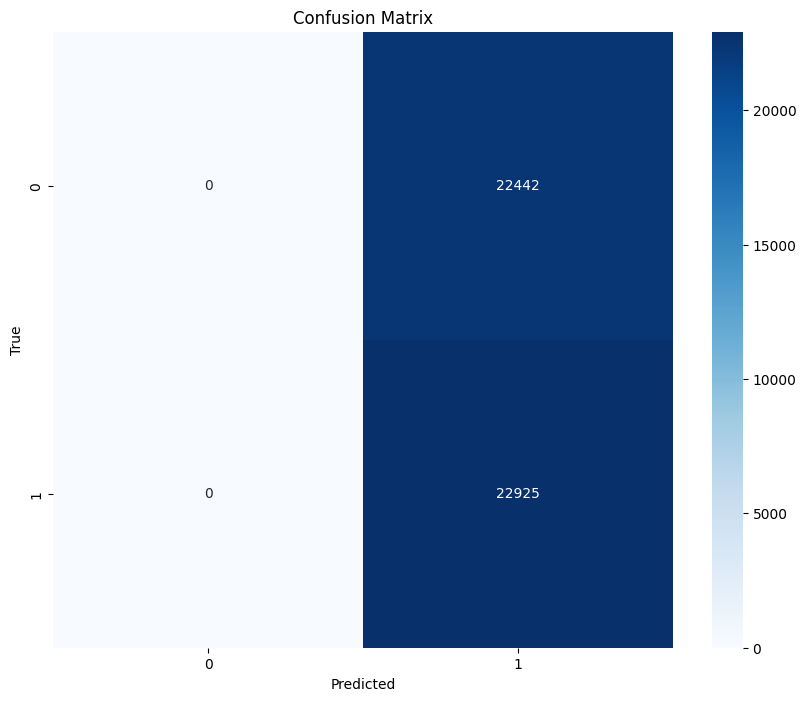

In [15]:
f1_metrics['word_to_vec_loaded'] = train_and_evaluate_model(df['word_to_vec_loaded'], df['ttype'])

Epoch 1/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6374 - loss: 0.6338 - precision_1: 0.6302 - recall_1: 0.6901
Epoch 2/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.6687 - loss: 0.6044 - precision_1: 0.6625 - recall_1: 0.7102
Epoch 3/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.6792 - loss: 0.5941 - precision_1: 0.6716 - recall_1: 0.7176
Epoch 4/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.6878 - loss: 0.5840 - precision_1: 0.6832 - recall_1: 0.7148
Epoch 5/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6922 - loss: 0.5765 - precision_1: 0.6884 - recall_1: 0.7134
Epoch 6/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6973 - loss: 0.5714 - precision_1: 0.6935 - recall_1: 0.7202
Epoch 7/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7035 - loss: 0.5621 - precision_1: 0.6969 - recall_1: 0.7321
Epoch 8/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7068 - loss: 0.5578 -

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,901 (347.27 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,268 (231.52 KB)

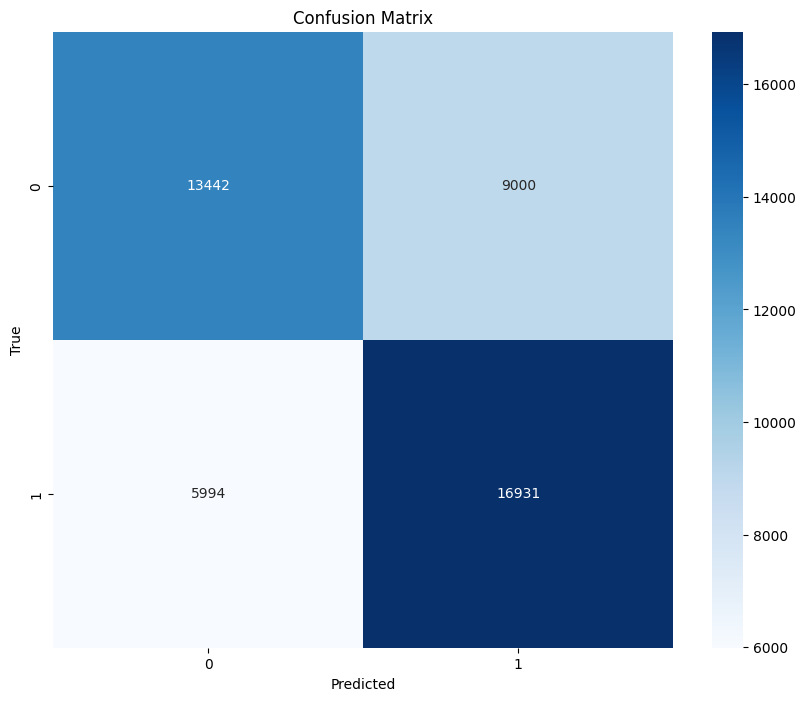

In [16]:
f1_metrics['w2v_features'] = train_and_evaluate_model(df['w2v_features'], df['ttype'])

Epoch 1/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.6481 - loss: 0.6212 - precision_2: 0.6443 - recall_2: 0.6785
Epoch 2/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.6856 - loss: 0.5860 - precision_2: 0.6811 - recall_2: 0.7145
Epoch 3/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6936 - loss: 0.5755 - precision_2: 0.6876 - recall_2: 0.7241
Epoch 4/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.6997 - loss: 0.5692 - precision_2: 0.6927 - recall_2: 0.7305
Epoch 5/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.7041 - loss: 0.5621 - precision_2: 0.7005 - recall_2: 0.7295
Epoch 6/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7122 - loss: 0.5532 - precision_2: 0.7050 - recall_2: 0.7447
Epoch 7/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.7181 - loss: 0.5469 - precision_2: 0.7115 - recall_2: 0.7482
Epoch 8/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7200 - loss: 0.5423 -

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,901 (347.27 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,268 (231.52 KB)

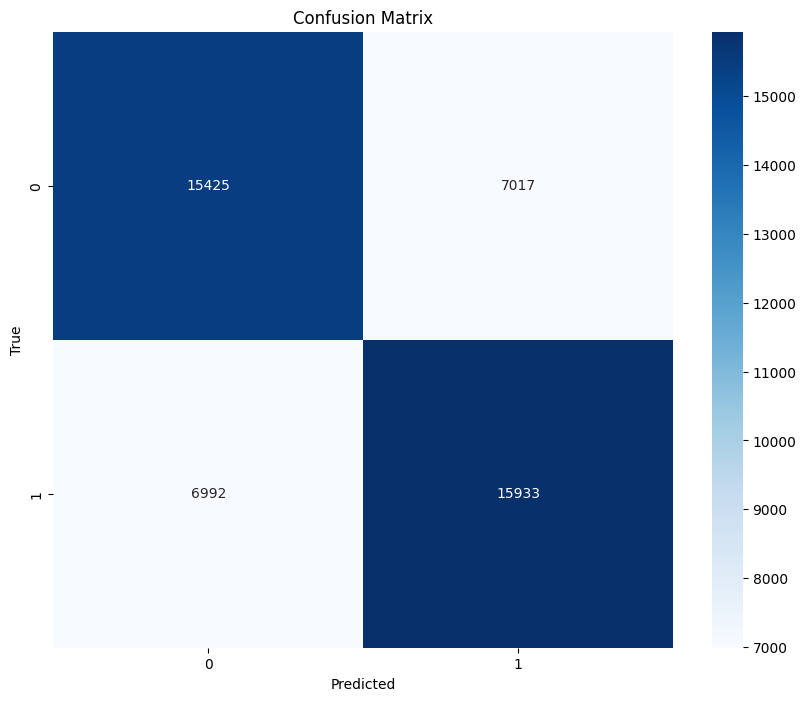

In [17]:
f1_metrics['fast_text_features'] = train_and_evaluate_model(df['fast_text_features'], df['ttype'])

Epoch 1/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.6462 - loss: 0.6281 - precision_3: 0.6426 - recall_3: 0.6804
Epoch 2/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.6802 - loss: 0.5961 - precision_3: 0.6802 - recall_3: 0.6966
Epoch 3/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.6913 - loss: 0.5817 - precision_3: 0.6921 - recall_3: 0.7051
Epoch 4/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7018 - loss: 0.5691 - precision_3: 0.7015 - recall_3: 0.7152
Epoch 5/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.7081 - loss: 0.5589 - precision_3: 0.7067 - recall_3: 0.7270
Epoch 6/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.7165 - loss: 0.5495 - precision_3: 0.7174 - recall_3: 0.7265
Epoch 7/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7249 - loss: 0.5398 - precision_3: 0.7260 - recall_3: 0.7343
Epoch 8/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7301 - loss: 0.5312 -

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,701 (647.27 KB)

 Trainable params: 55,233 (215.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 110,468 (431.52 KB)

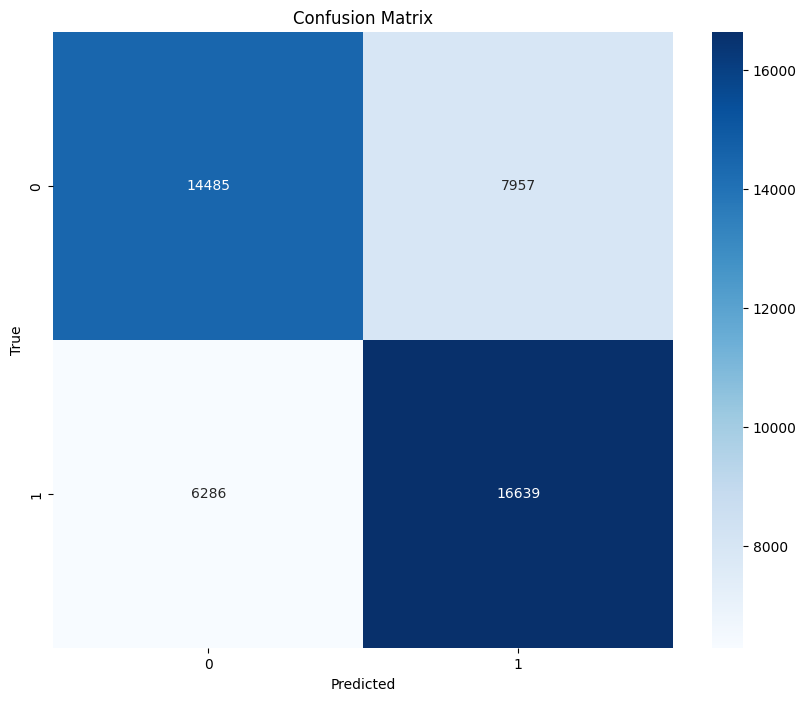

In [18]:
f1_metrics['fast_text_loaded'] = train_and_evaluate_model(df['fast_text_loaded'], df['ttype'])

In [19]:
f = pd.read_csv('/content/pos_frequencies_dataset.csv')
f.to_pickle('/content/pos_frequencies_dataset.pkl')

Epoch 1/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.5265 - loss: 0.6909 - precision_4: 0.5263 - recall_4: 0.6243
Epoch 2/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5381 - loss: 0.6893 - precision_4: 0.5379 - recall_4: 0.6232
Epoch 3/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.5384 - loss: 0.6890 - precision_4: 0.5368 - recall_4: 0.6235
Epoch 4/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.5376 - loss: 0.6882 - precision_4: 0.5353 - recall_4: 0.6514
Epoch 5/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.5377 - loss: 0.6880 - precision_4: 0.5374 - recall_4: 0.6501
Epoch 6/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5399 - loss: 0.6875 - precision_4: 0.5390 - recall_4: 0.6488
Epoch 7/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.5382 - loss: 0.6876 - precision_4: 0.5361 - recall_4: 0.6545
Epoch 8/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.5403 - loss: 0.6871 -

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,573 (209.27 KB)

 Trainable params: 17,857 (69.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,716 (139.52 KB)

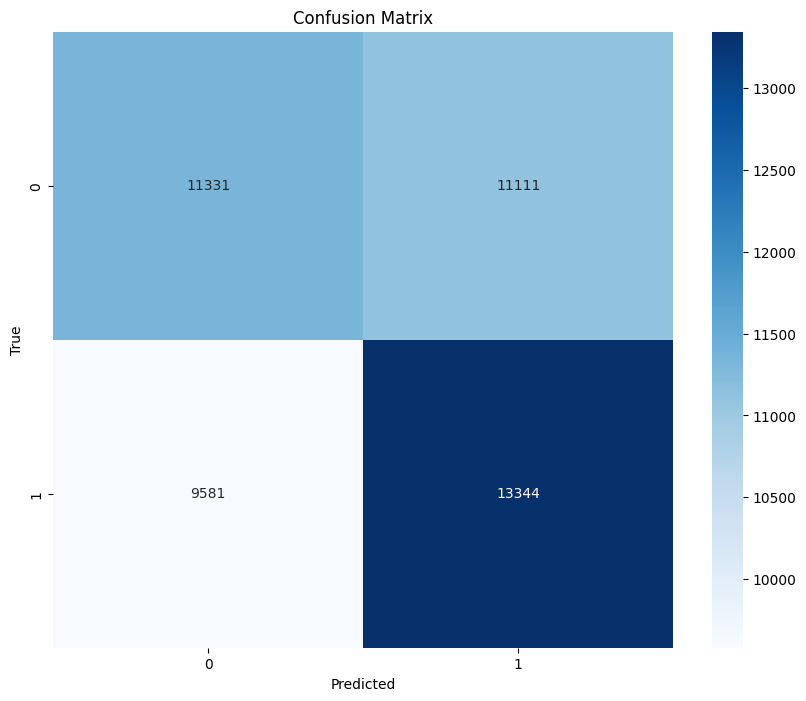

In [20]:
file_path = '/content/pos_frequencies_dataset.pkl'

with open(file_path, 'rb') as f:
    pos_frequencies_dataset = np.array(dill.load(f))

f1_metrics['pos_frequencies_dataset'] = train_and_evaluate_model(pos_frequencies_dataset, df['ttype'])

In [21]:
i = pd.read_csv('/content/linis_crowd_dataset.csv')

In [22]:
i.to_pickle('/content/linis_crowd_dataset.pkl')

Epoch 1/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.5285 - loss: 0.6907 - precision_5: 0.5289 - recall_5: 0.6092
Epoch 2/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5378 - loss: 0.6888 - precision_5: 0.5369 - recall_5: 0.6550
Epoch 3/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5379 - loss: 0.6887 - precision_5: 0.5364 - recall_5: 0.6517
Epoch 4/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5395 - loss: 0.6887 - precision_5: 0.5391 - recall_5: 0.6477
Epoch 5/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.5380 - loss: 0.6886 - precision_5: 0.5354 - recall_5: 0.6527
Epoch 6/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.5379 - loss: 0.6877 - precision_5: 0.5373 - recall_5: 0.6310
Epoch 7/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.5403 - loss: 0.6874 - precision_5: 0.5407 - recall_5: 0.6201
Epoch 8/10
5671/5671 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.5432 - loss: 0.6869 -

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,573 (209.27 KB)

 Trainable params: 17,857 (69.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,716 (139.52 KB)

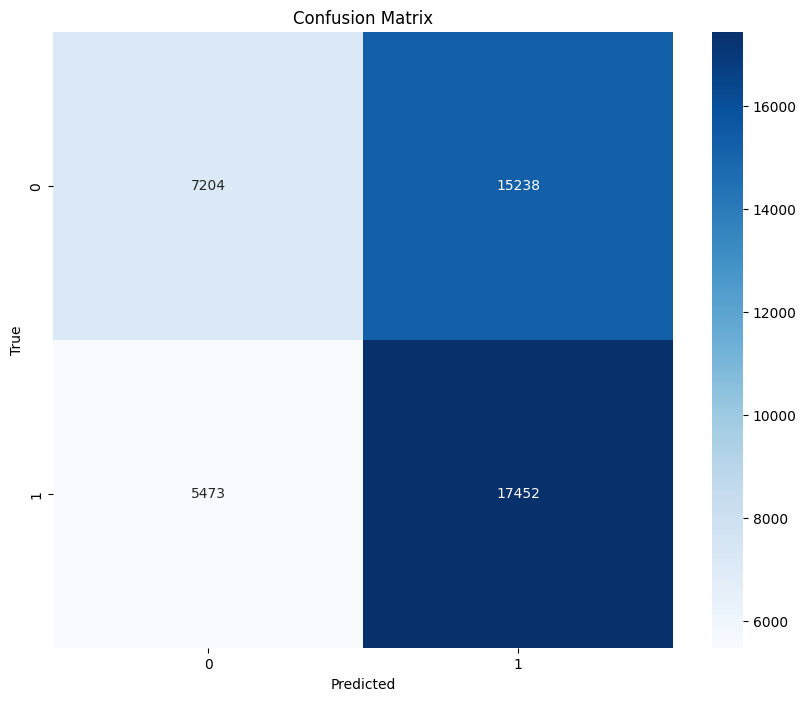

In [23]:
linis_crowd_dataset = np.array(pd.read_pickle('/content/pos_frequencies_dataset.pkl'))
f1_metrics['linis_crowd_dataset'] = train_and_evaluate_model(linis_crowd_dataset, df['ttype'])

In [ ]:
tfidf = np.array(pd.read_pickle('/content/tfidf_dataset (1).pkl'))
f1_metrics['tfidf'] = train_and_evaluate_model(tfidf, df['ttype'])

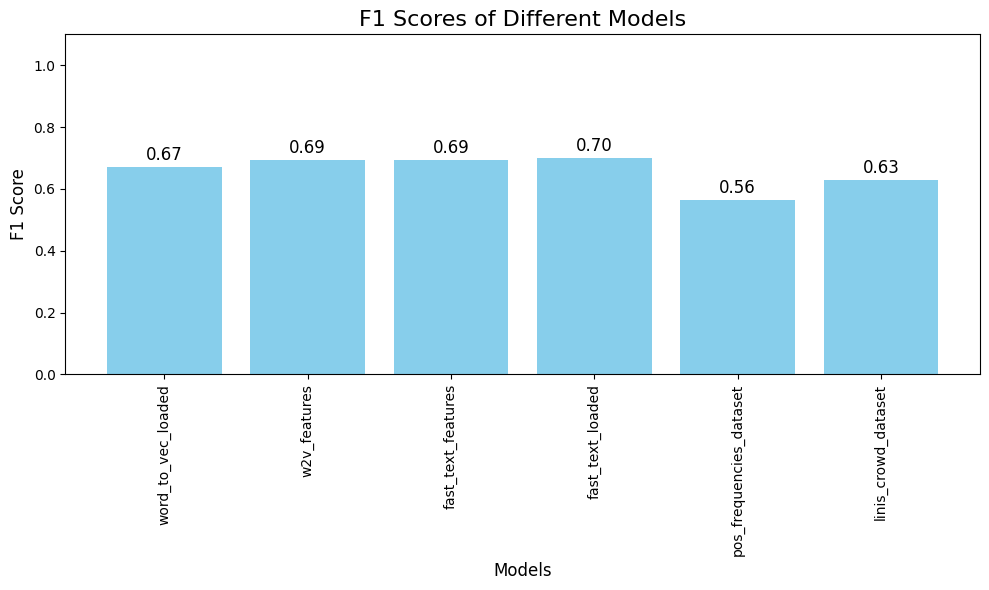

In [24]:
names = list(f1_metrics.keys())
values = list(f1_metrics.values())

plt.figure(figsize=(10, 6))
plt.bar(names, values, color='skyblue')

plt.xlabel('Models', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Scores of Different Models', fontsize=16)

for i, value in enumerate(values):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=90)

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [ ]:
f1_metrics['tfidf'] = train_and_evaluate_model(tfidf, df['ttype'])